In [1]:
from rdkit.Chem.Draw import IPythonConsole
import matplotlib.pyplot as plt
from collections import defaultdict
from rdkit.Chem import Draw
from collections import Counter
from tqdm import tqdm
import pandas as pd
import numpy as np
import os

import bblean
import bblean.plotting as plotting
import bblean.analysis as analysis
import bblean.similarity as iSIM

/home/acomajuncosa/miniconda3/envs/bblean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root = "/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation"
PATH_TO_SELECTED_COMPOUNDS = os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "selected_compounds")

In [3]:
def get_splits(path):
    splits = os.listdir(path)
    return [i.replace(".csv", "") for i in sorted(splits)]

def get_pockets():
    df = pd.read_csv("/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation/processed/pocket_detection_data.csv")
    pockets = [f"{i.replace('.pdb', '')}_pocket_{j}" for i, j in zip(df['File name'], df['Pocket number'])]
    return sorted(pockets)

def smiles_grid(smiles, per_row=4, size=(200, 200)):
    mols = [Chem.MolFromSmiles(s) for s in smiles]
    return Draw.MolsToGridImage(mols, molsPerRow=per_row, subImgSize=size, maxMols=10_000)

# Get splits (994)
SPLITS = get_splits(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", 'A_proteins'))

# Get pockets (276)
POCKETS = get_pockets()

In [4]:
df = pd.read_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "filtered_compounds.csv"))

In [5]:
MAX_SYNTHON = 3
SYNTHON_COUNTS = defaultdict(int)
KEEP = []

for id_ in tqdm(df['id']):

    if id_.startswith("m_") == False and id_.startswith("s_") == False:
        raise TypeError("ID not starting with m nor s. Please revise")
    
    
    synthons = id_.split("____")[1:]
    keep = True
    tmp_dict = defaultdict(int)

    # tmp dict with synthons
    for synthon in synthons:
        tmp_dict[synthon] += 1

    # check valid compound
    for synthon in synthons:
        if SYNTHON_COUNTS[synthon] + tmp_dict[synthon] <= MAX_SYNTHON:
            pass
        else:
            keep = False
            break

    # add compound if valid
    if keep == True:
        KEEP.append(True)
        for synthon in synthons:
            SYNTHON_COUNTS[synthon] += 1
        
    else:
        KEEP.append(False)
        

df['keep_synthon'] = KEEP
d = Counter(KEEP)
print(round(100 * d[True] / (d[True] + d[False]), 2), "%")

100%|██████████| 964993/964993 [00:01<00:00, 912227.69it/s]

17.3 %


In [6]:
df = df[df['keep_synthon']].reset_index(drop=True)

In [7]:
df

,split,index,n_targets,label,smiles,id,rd,MW,logp,QED,nsps_score,keep_synthon
0,Enamine_REAL_LeadLike_342,6157521,273.0,A_pockets,O=C1C=CC=C(C(=O)NCC2=CCCN(C(=O)C3=NNC(=O)C3)C2)N1,m_275592____25037044____13187268____15858220,0.000004,343.343,-0.8607,0.615409,16.800000,True
1,Enamine_REAL_LeadLike_402,204310,272.0,A_pockets,[N-]=[N+]=NC1CCN(C(=O)[C@@H]2CCCN2C(=O)C2=CC3=...,m_274552____23414938____15962996____15976146,0.000007,352.398,2.6837,0.520919,22.615385,True
2,Enamine_REAL_NaturalProducts_036,9440957,272.0,A_pockets,O=C1C=CC([C@@H]2OCC[C@H]2NC(=O)[C@@H]2OCCC[C@H...,s_11____22175474____14417596,0.000012,368.433,2.2839,0.867683,28.000000,True
3,Enamine_REAL_LeadLike_570,9708359,274.0,A_pockets,NC1=CC(N2C=C(C3=C(C(=O)N4CNC(=O)C4)NN=C3)N=N2)...,m_279130____28580338____28139450____28610894,0.000020,374.311,0.0473,0.554523,13.851852,True
4,Enamine_REAL_LeadLike_130,393311,275.0,A_pockets,O=C1NC[C@H]2CN(C(=O)OC3=CC=CC4=CC=CC=C43)C[C@@...,s_282070____22247592____23868088,0.000026,296.326,2.0164,0.875571,23.454545,True
...,...,...,...,...,...,...,...,...,...,...,...,...
166985,Enamine_REAL_LeadLike_823,1362303,50.0,B_pockets,CC(C)C1=NN(C2=CC=CC=C2)C(NC(=O)C(=O)N2CCC3=C(C...,s_2718____29032614____10303748,0.999897,446.433,3.2610,0.603996,13.875000,True
166986,Enamine_REAL_LeadLike_492,3188975,50.0,B_pockets,O=C(NC1=CC2=C(C=C1SC1=CC=CC=C1)OCCO2)C(=O)N1CC...,s_2718____29023816____2677862,0.999901,386.429,1.7506,0.781781,15.814815,True
166987,Enamine_REAL_LeadLike_022,8936475,50.0,B_pockets,O=[N+]([O-])C1=CC(I)=CC=C1NC1=CC(O)=CC(F)=C1,s_27____25562128____27423980,0.999910,374.109,3.7877,0.487163,10.210526,True
166988,Enamine_REAL_LeadLike_611,3028138,50.0,B_pockets,O=C(O)C1=CC=C(C(=O)N2CCN(CC3=C4OCOC4=CC=C3Cl)C...,s_274370____34739058____15268268,0.999950,402.834,2.7249,0.846685,16.250000,True


In [8]:
SMILES = df['smiles'].tolist()

In [9]:
fps = bblean.fps_from_smiles(SMILES, pack=True, n_features=2048, kind="ecfp6")

In [10]:
fps.shape

(166990, 256)

In [11]:
average_sim = iSIM.jt_isim(fps)
isim_sigma = iSIM.estimate_jt_std(fps)
print(f"Estimated similarity mean and std: {average_sim:.3f}, std: {isim_sigma:.3f}")
optimal_threshold = average_sim + 4 * isim_sigma
# optimal_threshold = 0.5
optimal_threshold = 0.3

Estimated similarity mean and std: 0.095, std: 0.027


In [12]:
bb_tree = bblean.BitBirch(branching_factor=50, threshold=optimal_threshold, merge_criterion="diameter")
bb_tree.fit(fps)

BitBirch(threshold=0.3, branching_factor=50, merge_criterion='diameter')

In [13]:
clusters = bb_tree.get_cluster_mol_ids()
print(f"Number of clusters: {len(clusters)}")
print("Number of singletons", sum(1 for c in clusters if len(c) == 1))

Number of clusters: 128944
Number of singletons 108893


In [14]:
bb_tree.recluster_inplace(iterations=5, extra_threshold=isim_sigma, shuffle=False, verbose=True)

Current number of clusters: 128944
Current number of singletons: 108893
Current number of clusters: 117906
Current number of singletons: 91721
Current number of clusters: 112102
Current number of singletons: 82643
Current number of clusters: 109197
Current number of singletons: 77909
Current number of clusters: 107600
Current number of singletons: 75245
Final number of clusters: 106711
Final number of singletons: 73694


BitBirch(threshold=0.43456221180014326, branching_factor=50, merge_criterion='diameter')

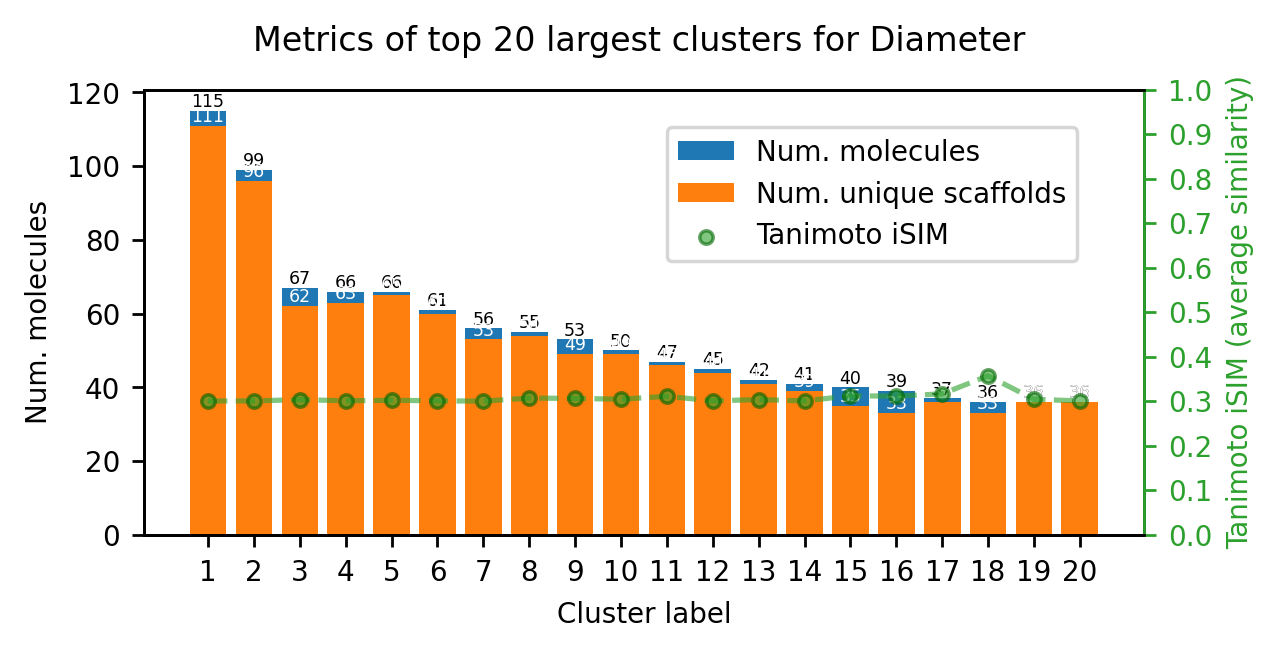

In [15]:
# First we run a cluster analysis on the resulting ids
clusters = bb_tree.get_cluster_mol_ids()
ca = analysis.cluster_analysis(clusters, fps, SMILES)

# Afterwards we can use the utility functions on the bblean.plotting module
plotting.summary_plot(ca, title="Diameter")
plt.show()

In [16]:
# Total clusters
print("Number of clusters: ", len(clusters))

# Clusters with more than 10 molecules
large_clusters = [c for c in clusters if len(c) > 10]
print("Number of clusters with more than 10 molecules: ", len(large_clusters))

Number of clusters:  106711
Number of clusters with more than 10 molecules:  431


In [17]:
ind_to_cluster_label = dict()
for cluster_number, inds in enumerate(clusters):
    for ind in inds:
        ind_to_cluster_label[ind] = cluster_number

df["cluster_number"] = [ind_to_cluster_label[i] for i in range(len(df))]


In [24]:
df.drop_duplicates(subset=['cluster_number'], keep='first')

,split,index,n_targets,label,smiles,id,rd,MW,logp,QED,nsps_score,keep_synthon,cluster_number
0,Enamine_REAL_LeadLike_342,6157521,273.0,A_pockets,O=C1C=CC=C(C(=O)NCC2=CCCN(C(=O)C3=NNC(=O)C3)C2)N1,m_275592____25037044____13187268____15858220,0.000004,343.343,-0.8607,0.615409,16.800000,True,5942
1,Enamine_REAL_LeadLike_402,204310,272.0,A_pockets,[N-]=[N+]=NC1CCN(C(=O)[C@@H]2CCCN2C(=O)C2=CC3=...,m_274552____23414938____15962996____15976146,0.000007,352.398,2.6837,0.520919,22.615385,True,38844
2,Enamine_REAL_NaturalProducts_036,9440957,272.0,A_pockets,O=C1C=CC([C@@H]2OCC[C@H]2NC(=O)[C@@H]2OCCC[C@H...,s_11____22175474____14417596,0.000012,368.433,2.2839,0.867683,28.000000,True,27691
3,Enamine_REAL_LeadLike_570,9708359,274.0,A_pockets,NC1=CC(N2C=C(C3=C(C(=O)N4CNC(=O)C4)NN=C3)N=N2)...,m_279130____28580338____28139450____28610894,0.000020,374.311,0.0473,0.554523,13.851852,True,4764
4,Enamine_REAL_LeadLike_130,393311,275.0,A_pockets,O=C1NC[C@H]2CN(C(=O)OC3=CC=CC4=CC=CC=C43)C[C@@...,s_282070____22247592____23868088,0.000026,296.326,2.0164,0.875571,23.454545,True,30270
...,...,...,...,...,...,...,...,...,...,...,...,...,...
166983,Enamine_REAL_LeadLike_608,4806977,50.0,B_pockets,O=C(NS(=O)(=O)CCN1C(=O)C2=CC=CC=C2C1=O)C1=CC=N...,s_2740____884078____22606096,0.999781,399.388,0.0851,0.601449,13.785714,True,102554
166984,Enamine_REAL_LeadLike_611,264615,50.0,B_pockets,O=C(NC1=CC=C(NCC2=CC=CC=N2)C=C1)[C@H]1CC2=CC(F...,s_272430____30474036____26394002,0.999827,376.435,3.4858,0.637823,15.535714,True,66184
166987,Enamine_REAL_LeadLike_022,8936475,50.0,B_pockets,O=[N+]([O-])C1=CC(I)=CC=C1NC1=CC(O)=CC(F)=C1,s_27____25562128____27423980,0.999910,374.109,3.7877,0.487163,10.210526,True,80361
166988,Enamine_REAL_LeadLike_611,3028138,50.0,B_pockets,O=C(O)C1=CC=C(C(=O)N2CCN(CC3=C4OCOC4=CC=C3Cl)C...,s_274370____34739058____15268268,0.999950,402.834,2.7249,0.846685,16.250000,True,53617


In [ ]:
df

[15076,
 15685,
 16546,
 16899,
 17926,
 18707,
 18953,
 19103,
 19728,
 19730,
 20130,
 20306,
 20528,
 21791,
 21918,
 22965,
 23500,
 24027,
 25664,
 25788,
 26003,
 26626,
 27094,
 27117,
 27476,
 27767,
 29030,
 30573,
 32491,
 32568,
 35492,
 35817,
 37302,
 37569,
 38263,
 38432,
 38503,
 38626,
 38653,
 39332,
 39672,
 39725,
 40165,
 40548,
 40611,
 40755,
 41523,
 41894,
 43437,
 44030,
 44511,
 44892,
 44986,
 46422,
 46547,
 46675,
 46703,
 46805,
 47103,
 47543,
 47671,
 47734,
 48139,
 48384,
 49029,
 49092,
 49174,
 49717,
 50758,
 50941,
 51105,
 51187,
 51530,
 52277,
 52421,
 53132,
 54794,
 55195,
 56590,
 56791,
 56965,
 56974,
 57300,
 58495,
 58516,
 58544,
 59184,
 59385,
 61412,
 61901,
 64381,
 66048,
 70419,
 77748,
 82072,
 84833,
 85770,
 92782,
 92887,
 98659,
 100507,
 103491,
 104004,
 104465,
 110543,
 114957,
 123725,
 125833,
 127718,
 128748,
 139311,
 140151,
 140279,
 141165,
 141457]